In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR

from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm
import json
import cv2
import matplotlib.pyplot as plt
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import (
    plot_some_images ,read_images ,
    pre_hard_skeletonize , pre_soft_skeletonize,
    compute_confution_matrix,draw_mask,
    denorm,TP_TN_FP_FN)
from utils.preprocessing import (
    WhiteTopHat , CLAHE , normalize_xca , 
    morph_binary_mask , DoubleClahe,laplacian_pyramid_enhance)
from utils.dataset import  UnetDataset , ValidUnetDataset , make_dataloader
from models.nnunet import nnUnet
from models.nnunet_blocks import nnUnetv2
from models.swin_encoder import SwinEncoder , SwinUperNet
from utils.losses import MainLossFn
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [2]:
args = {
    "base_path" : "./dataset/syntax",
    "in_c" : 3,
    "base_channel" :32,
    "image_shape" : (448,448),
    "abs_class_count":17,
    "attention" : True,
    "k":40,
    "batch_size" : 4,
    "num_workers" : 10,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 1e-4,
    "momentum" : 0.99,
    "weight_decay" : 0.001,
    "epcohs":30,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "unet_depth":6,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.0,
    "f_gamma":2.0,
    "resize_binary":[True,(224,224)],
    "loss_coefs":{"CE":1.0,"Second":1.0},
    "swin_head" : "costume",
    "swin_type":"swin_v2_b",
    "output_base_path" : "./outputs",
    "name" : "binary_segmentation-swin-sampler-sch-no_pre-no_cldice-no_bg-focal",
    "deep_super_vision" : False,
    "just_binary_trining":True,
    "use_sch":True,
    "use_amp":False,
    "f_alpha":None,
    "remove_bg":True
}
args["class_count"] = 2 if args["just_binary_trining"] else 26
if args["just_binary_trining"]:
    class_map = {
        1:"fg"
    }
    
else:
    class_map = {
        1: '1',2: '2', 3: '3',4: '4',
        5: '5',6: '6',7: '7',8: '8',
        9: '9',10: '9a',11: '10',12: '10a',
        13: '11',14: '12',15: '12a',16: '13',
        17: '14',18: '14a',19: '15',20: '16',
        21: '16a',22: '16b',23: '16c',
        24: '12b',25: '14b'
    }
abs_class_map = [
    1,2,3,4,5,6,7,
    8,9,9,10,10,11,
    12,12,13,14,14,
    15,16,16,16,16,
    12,14
]
"""
    1:1,2:2,3:3,4:4,5:5,6:6,7:7,8:8,9:9,
    10:9,11:10,12:10,13:11,14:12,15:12,
    16:13,17:14,18:14,19:15,20:16,21:16,
    22:16,23:16,24:12,25:14
"""
train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
train_pixel_counts = [
    253576361,664435,686727,661957,
    480566,591829,816901,685677,570436,
    470633,124025,23866,1079,507754,151219,
    336857,597880,241117,98167,66890,322098,
    49426,63543,36457,164558,153542
]
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
# losses_keys = ["total loss","FCE loss",args["loss_type"]]

losses_keys = [
    "total loss",
    "binary loss",
    # "bianry cldice loss ",
    "binary dice loss",
    "binary BCE loss"
    # f"{args["loss_type"]}_abs",
    # f"{args["loss_type"]}_main",
]
out_counts = 5 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0]

In [3]:
def class_weighting(method,class_counts,**kwargs):
    if(kwargs["use_pixel_counts"]):
        print("using pixel counts")
        with open("./data/train_pixel_counts.json","r") as f:
            train_class_counts = json.load(f)
        counts = [0]*(len(train_class_counts))
        for k,v in train_class_counts.items():
            counts[int(k)] = int(v)
        counts = np.array(counts,dtype=np.float64)
    else :
        print("using class counts")
        counts = np.array(class_counts,dtype=np.float64)

    if(method=="median"):
        print("median weights being used")
        median_count = np.median(counts)
        weights = median_count/np.array(counts)
        
    elif(method=="log"):
        print("log weights being used")
        total = np.sum(counts)
        weights = np.log(total/np.array(counts))
        weights = (weights / weights.mean())
        weights[0]=0.1
    elif(method=="beta"):
        print("beta weights being used")
        b = kwargs["b"]
        weights = (1-b)/(1-np.power(b,counts))
        weights = weights / weights.sum()
        weights[12] = 0.25
    else:
        print("no class weights being used")
        return None
    return weights.tolist()
args["f_alpha"] = class_weighting(method="none",class_counts=train_class_counts,b=0.999999,use_pixel_counts=False)
args["f_alpha"]

using class counts
no class weights being used


In [4]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [5]:
train_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    A.Resize(*args["image_shape"]),
    A.OneOf([
        A.ElasticTransform(
            alpha=120, 
            sigma=120 * 0.05, 
            p=1.0
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, p=1.0),
    ], p=0.7),


    A.Affine(
        scale=(0.8, 1.2),             
        translate_percent=(-0.1, 0.1), 
        rotate=(-30, 30),         
        shear=(-10, 10),      
        

        fill=0,           
        fill_mask=0,                 
        border_mode=cv2.BORDER_CONSTANT, 
        
        fit_output=False,  
        p=0.7
    ),

    # A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),

    # A.RandomBrightnessContrast(
    #     brightness_limit=0.2, 
    #     contrast_limit=0.2, 
    #     p=0.5
    # ),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    # A.Lambda(image=morph_binary_mask, p=1),

    # A.Lambda(image=normalize_xca)
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
        max_pixel_value=255.0
    )

],additional_targets={'binary_mask': 'mask', 'abs_mask': 'mask'})

test_transforms = A.Compose([
    # A.RandomCrop(args["image_shape"][0],args["image_shape"][1]),
    A.Resize(*args["image_shape"]),
    # A.Lambda(image=normalize_xca),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
        max_pixel_value=255.0
    )
],additional_targets={'binary_mask': 'mask', 'abs_mask': 'mask'})
# train_preprocess = v2.Compose([
#     # WhiteTopHat(kernel_size=(50,50)),
#     # CLAHE()
#     DoubleClahe(kernel_size=(3,3),tile_grid=(10,10))
# ])
train_preprocess = None


In [6]:

train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_pixel_counts),
    in_c = args["in_c"],
    abs_class_map = abs_class_map,
    resize_binary = args["resize_binary"],
    k = args["k"]
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None,
    in_c=args["in_c"],
    abs_class_map = abs_class_map,
    resize_binary = args["resize_binary"],
    k = args["k"]
)
# print(sampler_weights)
train_ds = UnetDataset(
    transform = train_transforms,
    data = train_images,
    base_size=args["image_shape"]
)
valid_ds = UnetDataset(
    transform = test_transforms,
    data = valid_images,
    base_size=args["image_shape"]
)

train_loader = make_dataloader(train_ds,args,valid=False,sampler_weights=sampler_weights)
valid_loader = make_dataloader(valid_ds,args,valid=True,sampler_weights=None)

max count is :  816901
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

using weighted sampler here
valid with no sampler


torch.Size([4, 3, 448, 448])
torch.Size([4, 1])
torch.Size([4, 1, 448, 448])
torch.Size([4, 448, 448])
torch.Size([4, 448, 448])
[0 1]
[0 5 6 7 8 9]
[ 0  5  6  7  8 10]


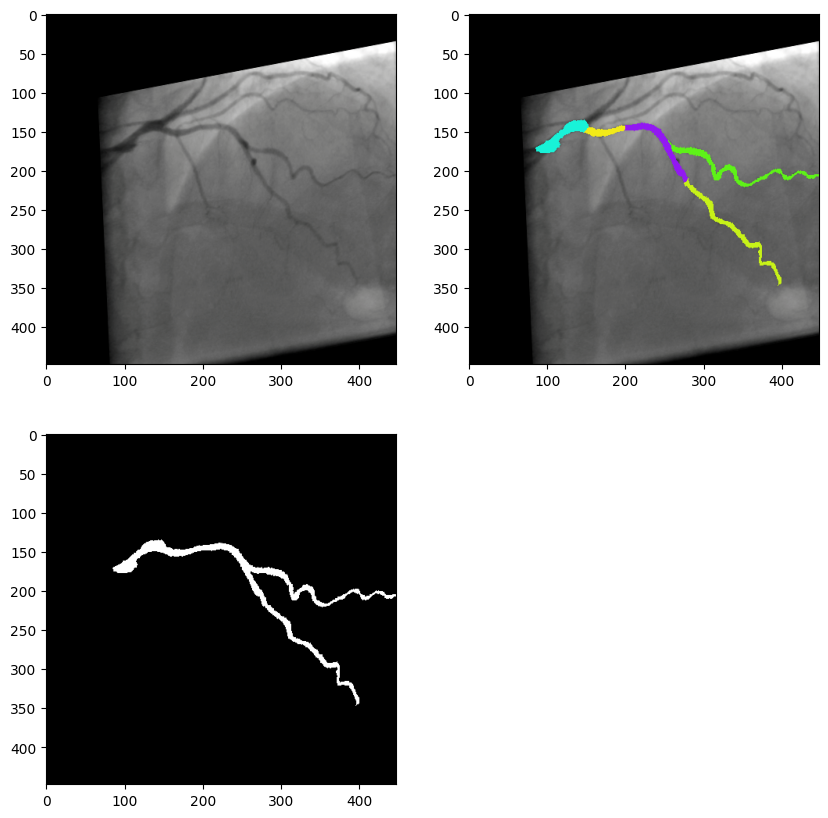

In [7]:
colors = np.array([
    (242,  24,  24),   # Red
    (242,  77,  24),   # Red-Orange
    (242, 129,  24),   # Orange
    (242, 181,  24),   # Yellow-Orange
    ( 24, 242, 216),   # Cyan
    (242, 234,  24),   # Yellow
    (146,  24, 242),   # Purple
    (199, 242,  24),   # Yellow-Green
    (146, 242,  24),   # Lime
    ( 94, 242,  24),   # Green
    (242,  24, 181),   # Fuchsia
    ( 42, 242,  24),   # Green (brighter)
    ( 94,  24, 242),   # Violet
    ( 24, 242,  59),   # Spring Green
    (242,  24, 129),   # Pink
    ( 24, 242, 111),   # Aquamarine
    ( 24, 242, 164),   # Turquoise
    ( 24, 164, 242),   # Azure
    (199,  24, 242),   # Magenta
    ( 24, 216, 242),   # Sky Blue
    ( 24, 111, 242),   # Blue
    (242,  24, 234),   # Hot Pink
    ( 24,  59, 242),   # Royal Blue
    ( 42,  24, 242),   # Indigo
    (242,  24,  77),   # Rose
], dtype=np.uint8)

for img,side_label,binary_mask,abs_mask,mask in train_loader:
    print(img.shape)
    print(side_label.shape)
    print(binary_mask.shape)
    print(abs_mask.shape)
    print(mask.shape)
    ### binary check 
    index=2
    print(np.unique(binary_mask[index].numpy()))
    ### abs check 
    img = denorm(img[index],mean=IMAGENET_MEAN,std=IMAGENET_STD)
    plt.figure(figsize=(10,10))
    plt.subplot(2,2,1)
    print(np.unique(abs_mask[index].numpy()))
    print(np.unique(mask[index].numpy()))
    colored_16 = draw_mask(image=img,mask=abs_mask[index].numpy(),colors=colors)
    plt.imshow(img)
    plt.subplot(2,2,2)
    colored_25 = draw_mask(image=img,mask=mask[index].numpy(),colors=colors)
    plt.imshow(colored_25)
    plt.subplot(2,2,3)
    plt.imshow(binary_mask[index][0].numpy(),cmap="gray")
    break

In [8]:
# plot_some_images(train_images, train_transforms, mean=IMAGENET_MEAN,std=IMAGENET_STD,image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [ ]:
model = SwinEncoder(args).to(args["device"])
# model.load_state_dict(torch.load("./outputs/2025-11-27 10:45:17.854237 [swin-multi_task-main_binary_side]/model.pth"))
loss_fn = MainLossFn(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     momentum=args["momentum"],
#     lr=args["lr"],
#     nesterov=True,
#     weight_decay=args["weight_decay"]
# )
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=args["lr"], 
    betas=(0.9, 0.999), 
    eps=1e-08, 
    weight_decay=args["weight_decay"]
)
if(args["use_sch"]):
    lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
else:
    lr_sch = None

recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map,class_count=args["class_count"])

best_model =trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)


loss is set to tversky


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

--- Total Norm ---
tensor(1.1008, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.1045, device='cuda:0')
--- Total Norm ---
tensor(0.9785, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7607, device='cuda:0')
--- Total Norm ---
tensor(0.9156, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7333, device='cuda:0')
--- Total Norm ---
tensor(0.9114, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7269, device='cuda:0')
--- Total Norm ---
tensor(0.9060, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7552, device='cuda:0')
--- Total Norm ---
tensor(0.8219, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9179, device='cuda:0')
--- Total Norm ---
tensor(0.8857, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.9232, device='cuda:0')
--- Total Norm ---
tensor(0.6987, device='cuda:0', grad_fn=<AddBackward0>) tensor(1.0367, device='cuda:0')
--- Total Norm ---
tensor(0.7089, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.8729, device='cuda:0')
--- Total Norm ---
tensor(0.6948, dev

  0%|          | 0/250 [00:00<?, ?it/s]

...

--- Total Norm ---
tensor(0.0920, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.4368, device='cuda:0')
--- Total Norm ---
tensor(0.0573, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.3390, device='cuda:0')
--- Total Norm ---
tensor(0.0570, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.2170, device='cuda:0')
--- Total Norm ---
tensor(0.0598, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.3131, device='cuda:0')
--- Total Norm ---
tensor(0.0890, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.5863, device='cuda:0')
--- Total Norm ---
tensor(0.0706, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.4469, device='cuda:0')
--- Total Norm ---
tensor(0.0657, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.4566, device='cuda:0')
--- Total Norm ---
tensor(0.0514, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.1977, device='cuda:0')
--- Total Norm ---
tensor(0.0759, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.6497, device='cuda:0')
--- Total Norm ---
tensor(0.0756, dev

  0%|          | 0/250 [00:00<?, ?it/s]

--- Total Norm ---
tensor(0.0659, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.4277, device='cuda:0')
--- Total Norm ---
tensor(0.0838, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.5311, device='cuda:0')
--- Total Norm ---
tensor(0.0755, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.4160, device='cuda:0')
--- Total Norm ---
tensor(0.0614, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.3765, device='cuda:0')
--- Total Norm ---
tensor(0.0555, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.2379, device='cuda:0')
--- Total Norm ---
tensor(0.0514, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.3411, device='cuda:0')
--- Total Norm ---
tensor(0.0874, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.5167, device='cuda:0')
--- Total Norm ---
tensor(0.0748, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.3729, device='cuda:0')
--- Total Norm ---
tensor(0.0767, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.7845, device='cuda:0')
--- Total Norm ---
tensor(0.0599, dev

  0%|          | 0/250 [00:00<?, ?it/s]

--- Total Norm ---
tensor(0.1071, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.5630, device='cuda:0')
--- Total Norm ---
tensor(0.0827, device='cuda:0', grad_fn=<AddBackward0>) tensor(0.4676, device='cuda:0')


In [ ]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"],
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
    just_binary_trining = args["just_binary_trining"],
    use_amp = args["use_amp"]
)